# Exploratory Data Analysis (EDA) for InsuranceQA Dataset
**Objective:** The goal of this notebook is to perform a thorough exploratory data analysis on the InsuranceQA dataset. We will load the data directly from Hugging Face, inspect its structure, analyze key characteristics like text length, and visualize the core vocabulary to inform our modeling strategy.




## 1. Setup and Data Loading

In this section, we will import all the necessary libraries for our analysis and **load the `deccan-ai/insuranceQA-v2` dataset from the Hugging Face Hub**. This initial step is crucial for setting up our environment.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from wordcloud import WordCloud

sns.set_style("whitegrid")


/Users/testsolutions/Documents/school/year3/term2/summative-chatbot/kover/.env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATASET_NAME = "deccan-ai/insuranceQA-v2"
print(f"Loading dataset: {DATASET_NAME}...")
raw_dataset = load_dataset(DATASET_NAME)

print("\nDataset loaded successfully!")
print("Dataset structure:")
print(raw_dataset)

Loading dataset: deccan-ai/insuranceQA-v2...

Dataset loaded successfully!
Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['input', 'output'],
        num_rows: 21325
    })
    validation: Dataset({
        features: ['input', 'output'],
        num_rows: 3354
    })
    test: Dataset({
        features: ['input', 'output'],
        num_rows: 3308
    })
})


## 2. Initial Inspection and Conversion

Description: Now that the data is loaded, we'll convert the training split into a pandas DataFrame. This format is more convenient for manipulation and analysis. We will also examine the first few rows to understand the data's format and content.



In [4]:
df_train = raw_dataset['train'].to_pandas()

print("First 5 rows of the training data:")
display(df_train.head())

print(f"\nTotal training examples: {len(df_train)}")
print(f"Columns: {df_train.columns.tolist()}")

First 5 rows of the training data:


,input,output
0,What Does Medicare IME Stand For?,According to the Centers for Medicare and Medi...
1,Is Long Term Care Insurance Tax Free?,"As a rule , if you buy a tax qualified long te..."
2,Can Husband Drop Wife From Health Insurance?,Can a spouse drop another spouse from health i...
3,Is Medicare Run By The Government?,Medicare Part A and Part B is provided by the ...
4,Is Medicare Run By The Government?,Definitely . It is ran by the Center for Medic...



Total training examples: 21325
Columns: ['input', 'output']


## 3. Text Length Analysis

Description: Here, we will analyze the distribution of lengths for both questions and answers. Understanding the length helps us make decisions later about maximum token lengths for our model, which can impact performance and memory usage.

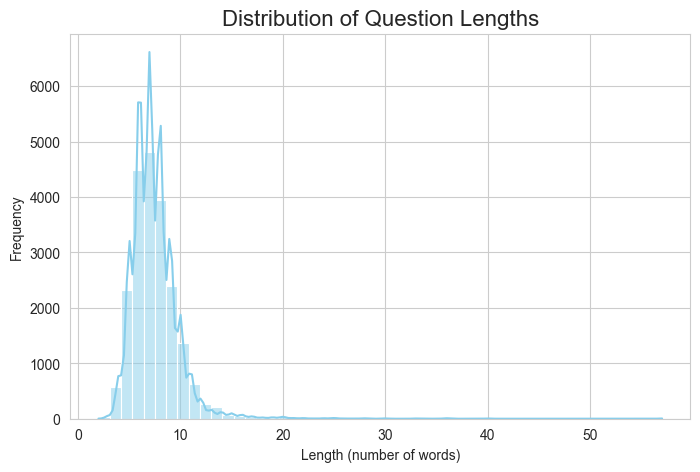

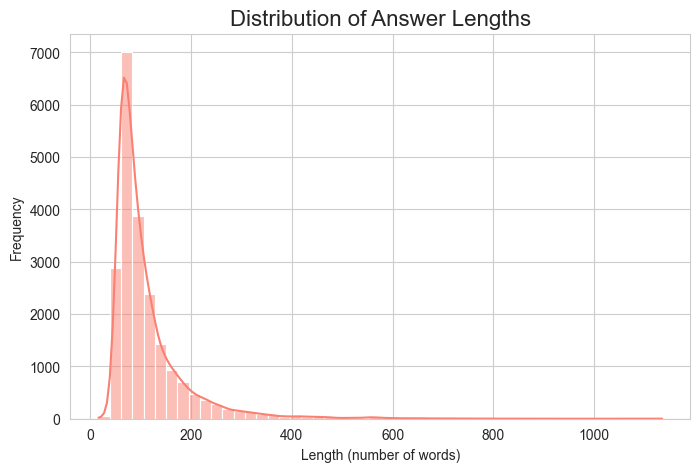

Summary Statistics for Text Lengths:


,question_length,answer_length
count,21325.000000,21325.000000
mean,7.489941,111.824431
std,2.374550,76.283356
min,2.000000,16.000000
25%,6.000000,67.000000
50%,7.000000,87.000000
75%,8.000000,125.000000
max,57.000000,1135.000000


In [ ]:
def plot_length_distribution(lengths, title, color='skyblue'):
    """Plots a histogram for the distribution of text lengths."""
    plt.figure(figsize=(8, 5))
    sns.histplot(lengths, bins=50, color=color, kde=True)
    plt.title(title, fontsize=16)
    plt.xlabel("Length (number of words)")
    plt.ylabel("Frequency")
    plt.show()

df_train['question_length'] = df_train['input'].str.split().str.len()
plot_length_distribution(df_train['question_length'], "Distribution of Question Lengths", color='skyblue')

df_train['answer_length'] = df_train['output'].str.split().str.len()
plot_length_distribution(df_train['answer_length'], "Distribution of Answer Lengths", color='salmon')

print("Summary Statistics for Text Lengths:")
display(df_train[['question_length', 'answer_length']].describe())

**Observations**

- **Questions:** The questions are typically short and direct.
    * The **mean length is approximately 7.5 words**, with 75% of questions being 8 words or less.
    * The distribution is tightly clustered, as shown by the low standard deviation (~2.4 words) and the sharp peak in the histogram. There is a notable outlier with a maximum length of 57 words, but this is rare.

- **Answers:** The answers are significantly more detailed and variable in length.
    * The **mean length is about 112 words**, but the standard deviation is very high (~76 words), indicating a wide range of answer lengths.
    * The histogram confirms this wide, right-skewed distribution, with a long tail extending to a maximum of 1,135 words.

This data structure is ideal for our task. The short, focused questions paired with long, comprehensive answers provide a perfect template for training a generative model to produce detailed, high-quality responses. We will need to be mindful of the maximum answer length when configuring our model's tokenization parameters.


## 4. Vocabulary Analysis with Word Cloud

Description: To get a high-level overview of the dataset's topics, we will generate a word cloud from all the answers in the training set. This visualization will highlight the most frequent and prominent terms, confirming the dataset's domain-specificity.

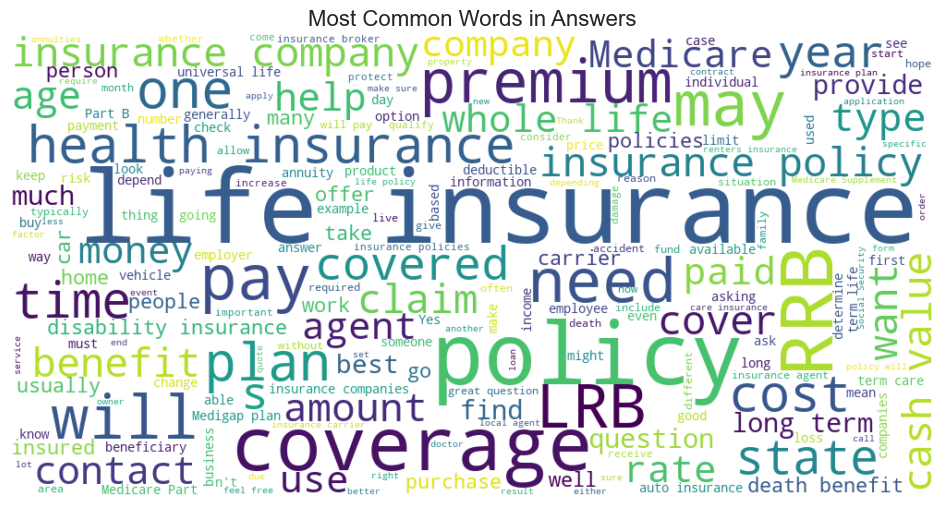

In [10]:
full_answer_text = ' '.join(df_train['output'].dropna())

wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white', 
    colormap='viridis'
).generate(full_answer_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Answers", fontsize=16)
plt.show()

**Observations**

- The word cloud is dominated by core insurance terminology such as insurance, policy, coverage, cost, and health.

- This visual evidence strongly confirms that the dataset is highly domain-specific, which is a key.